# Profit Prediction — Regression Project


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone


In [3]:

sns.set_style("whitegrid")
%matplotlib inline

PRIMARY = "#4C72B0"   
SECONDARY = "#DD8452"   
PALETTE = "deep"       
MEAN_COLOR = "#C0392B" 
MEDIAN_COLOR = "#2E7D32"  

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})


## 2. Load and Merge Data

In [4]:
customer = pd.read_csv("customer.csv")
orders = pd.read_csv("order.csv")
order_detail = pd.read_csv("order_detail.csv")
returned = pd.read_csv("returned.csv")
shipping = pd.read_csv("shipping.csv")
product = pd.read_csv("product.csv")



In [5]:
print("customer:", customer.shape)
print("orders:", orders.shape)
print("order_detail:", order_detail.shape)
print("returned:", returned.shape)
print("shipping:", shipping.shape)
print("product:", product.shape)


customer: (924, 3)
orders: (25033, 5)
order_detail: (49670, 8)
returned: (1172, 1)
shipping: (25033, 8)
product: (10246, 4)


### 2.0.1 Inspect Raw Tables
Before merging, we look at each table separately with `head` and `describe`.

In [6]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AB-10015,Aaron Bergman,Consumer


In [7]:
orders.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-18865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-14110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-17380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-18820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-14665,Medium,2014-12-13 00:00:00,EMEA


In [8]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [9]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [10]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [11]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [12]:
customer.describe()

,Customer ID,Customer Name,Segment
count,924,924,924
unique,924,795,3
top,AA-10315,Zuschuss Donatelli,Consumer
freq,1,2,476


In [13]:
orders.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,924,4,1428,7
top,AE-2011-9160,FO-14305,Medium,2014-11-25 00:00:00,APAC
freq,1,46,14344,59,5437


In [14]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [15]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [16]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [17]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.0 Fix Duplicate Customer Names
Some customers have several different Customer IDs. We unify the IDs so one customer's info isn't split up.

In [18]:
n_dup_names = customer["Customer Name"].duplicated().sum()
print("duplicated name in customer name:", n_dup_names)
canonical_lookup = customer.groupby("Customer Name")["Customer ID"].first().to_dict()
id_to_name = customer.set_index("Customer ID")["Customer Name"].to_dict()
id_to_canonical = {cid: canonical_lookup[name] for cid, name in id_to_name.items()}

orders["Customer ID"] = orders["Customer ID"].map(id_to_canonical).fillna(orders["Customer ID"])
customer = customer.drop_duplicates(subset=["Customer Name"], keep="first")

print("duplicated row after dropping", customer.shape[0])


duplicated name in customer name: 129
duplicated row after dropping 795


In [19]:
df = order_detail.merge(orders, on="Order ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(product[["Product ID", "Category", "Sub-Category"]], on="Product ID", how="left")

returned["Returned"] = 1
df = df.merge(returned[["Order ID", "Returned"]], on="Order ID", how="left")
df["Returned"] = df["Returned"].fillna(0)

df.head()


,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Category,Sub-Category,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-10575,Medium,...,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,Office Supplies,Labels,0.0
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Furniture,Furnishings,0.0
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Furniture,Bookcases,0.0
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Office Supplies,Binders,0.0
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Office Supplies,Art,0.0


In [20]:
df["Row ID"].unique()


array([    1,     2,     3, ..., 51288, 51289, 51290], shape=(49670,))

In [21]:
df.drop(columns="Row ID", inplace=True)


In [22]:
df.shape

(49670, 23)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  object 
 1   Product ID      49670 non-null  object 
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  object 
 8   Order Priority  49670 non-null  object 
 9   Order Date      49670 non-null  object 
 10  Market          49670 non-null  object 
 11  Customer Name   49670 non-null  object 
 12  Segment         49670 non-null  object 
 13  Shipping ID     49670 non-null  int64  
 14  Ship Date       49670 non-null  object 
 15  Ship Mode       49670 non-null  object 
 16  City            49670 non-null  object 
 17  State           49670 non-null 

### 2.1.1 Optimize dtypes
Categorical columns become `category` and numeric columns get lighter types. This doesn't change the results, it just reduces memory usage.

In [24]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Order ID        49670 non-null  object  
 1   Product ID      49670 non-null  object  
 2   Sales           49670 non-null  float32 
 3   Quantity        49670 non-null  int8    
 4   Discount        49670 non-null  float32 
 5   Profit          49670 non-null  float32 
 6   Shipping Cost   49670 non-null  float32 
 7   Customer ID     49670 non-null  object  
 8   Order Priority  49670 non-null  category
 9   Order Date      49670 non-null  object  
 10  Market          49670 non-null  category
 11  Customer Name   49670 non-null  object  
 12  Segment         49670 non-null  category
 13  Shipping ID     49670 non-null  int32   
 14  Ship Date       49670 non-null  object  
 15  Ship Mode       49670 non-null  category
 16  City            49670 non-null  category
 17  State       

In [25]:
df.describe(include="object")

,Order ID,Product ID,Customer ID,Order Date,Customer Name,Ship Date
count,49670,49670,49670,49670,49670,49670
unique,25033,10246,795,1428,795,1464
top,CA-2014-100111,OFF-AR-10003651,SW-10755,2014-09-03 00:00:00,Steven Ward,2014-11-22 00:00:00
freq,14,32,104,125,104,125


In [26]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840347,3.470787,0.143070,28.392263,26.041124,31632.081639,0.059996
std,485.960907,2.274854,0.212061,172.398849,56.870155,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.979980,0.002000,21043.000000,0.000000
25%,30.384001,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970001,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.829998,5.000000,0.200000,36.266400,23.968999,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980469,933.570007,46075.000000,1.000000


### 2.2 Numeric and Categorical Column Lists
Defined once here and reused across the EDA and statistical-test sections below.


In [27]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]

categorical_columns = [
    "Order Priority", "Market", "Category", "Sub-Category",
    "Segment", "Ship Mode", "City", "State", "Country", "Region",
    "Returned",
]


## 3. Exploratory Data Analysis (EDA)

### 3.1 Check Missing Values

In [34]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)


In [35]:
nan_percentage(df)


,Missing Count,Nan Percent
Order ID,0,0.0
Segment,0,0.0
Sub-Category,0,0.0
Category,0,0.0
Region,0,0.0
Country,0,0.0
State,0,0.0
City,0,0.0
Ship Mode,0,0.0
Ship Date,0,0.0


### 3.2 Check Duplicate Data

In [36]:
print("duplicated:", df.duplicated().sum())

duplicated: 0


### 3.3 Target Variable Distribution (Profit)

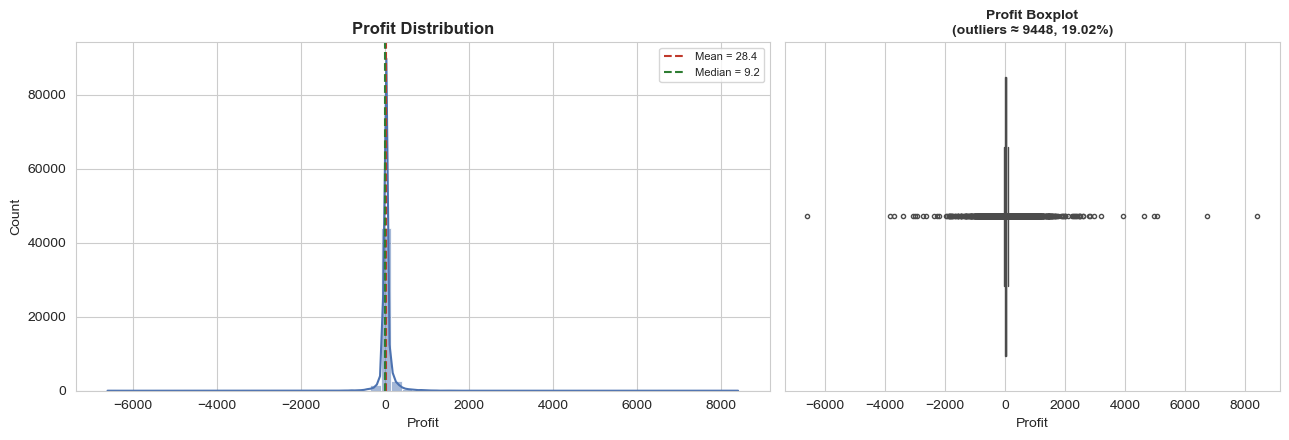

Skewness of Profit: 4.47


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})

p_mean = df["Profit"].mean()
p_median = df["Profit"].median()
q1, q3 = df["Profit"].quantile([0.25, 0.75])
iqr = q3 - q1
n_outliers = ((df["Profit"] < q1 - 1.5 * iqr) | (df["Profit"] > q3 + 1.5 * iqr)).sum()
pct_outliers = round(100 * n_outliers / len(df), 2)

sns.histplot(df["Profit"], bins=60, kde=True, color=PRIMARY, ax=axes[0])
axes[0].axvline(p_mean, color=MEAN_COLOR, linestyle="--", label=f"Mean = {p_mean:.1f}")
axes[0].axvline(p_median, color=MEDIAN_COLOR, linestyle="--", label=f"Median = {p_median:.1f}")
axes[0].set_title("Profit Distribution")
axes[0].set_xlabel("Profit")
axes[0].legend(fontsize=8)

sns.boxplot(x=df["Profit"], color=PRIMARY, ax=axes[1], fliersize=3)
axes[1].set_title(f"Profit Boxplot\n(outliers ≈ {n_outliers}, {pct_outliers}%)", fontsize=10)
axes[1].set_xlabel("Profit")

plt.tight_layout()
plt.show()

print(f"Skewness of Profit: {df['Profit'].skew():.2f}")


Profit isn't normally distributed and has some very large positive/negative values. This affects RMSE.

### 3.4 Check Outliers

In [38]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Profit"] < Q1 - 1.5 * IQR) | (df["Profit"] > Q3 + 1.5 * IQR)]
print("تعداد Outlierهای Profit:", outliers.shape[0])
print("درصد تقریبی:", round(outliers.shape[0] / len(df) * 100, 2))

تعداد Outlierهای Profit: 9448
درصد تقریبی: 19.02


### 3.5 Correlation Matrix

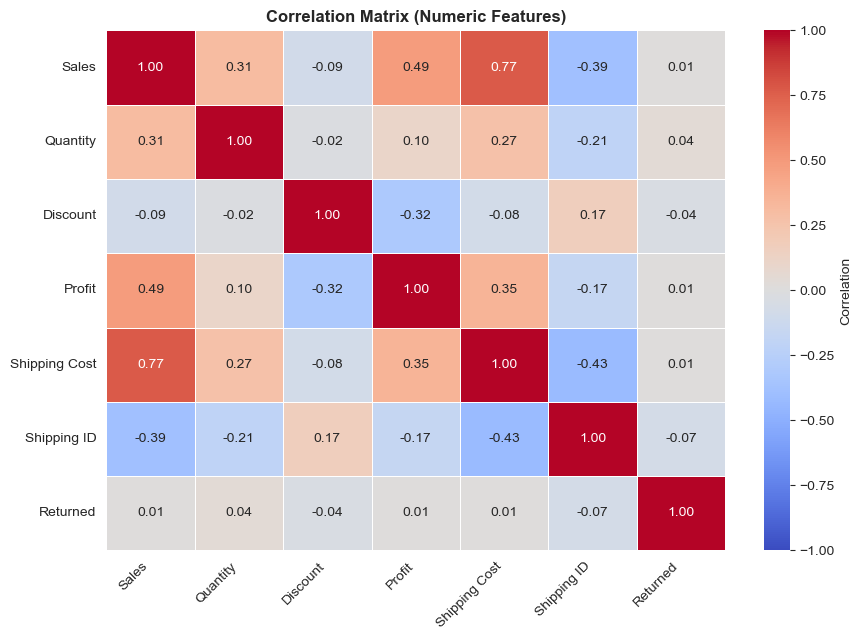

In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Matrix (Numeric Features)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 3.6 Relationship Between Categorical Features and Profit

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_25908\2042473260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y="Profit", order=order, palette=PALETTE, ax=ax, fliersize=2)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_25908\2042473260.py:7: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_25908\2042473260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y="Profit", order=order, palette=PALETTE, ax=ax, fliersize=2)
C:\Users\

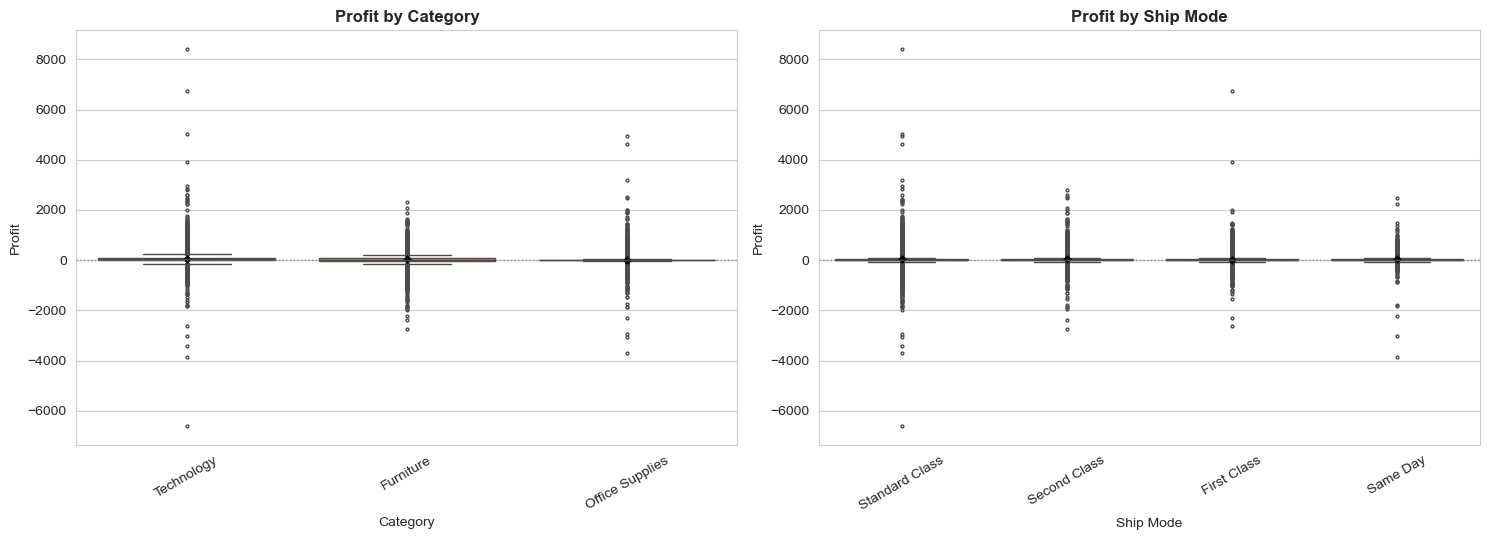

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, cat_col in zip(axes, ["Category", "Ship Mode"]):
    order = df.groupby(cat_col, observed=True)["Profit"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=cat_col, y="Profit", order=order, palette=PALETTE, ax=ax, fliersize=2)

    sns.pointplot(
        data=df, x=cat_col, y="Profit", order=order,
        color="black", markers="D", scale=0.6, errorbar=None, ax=ax, linestyle="none"
    )
    ax.set_title(f"Profit by {cat_col}")
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()


## 4. Data Preprocessing

### 4.1 Remove Duplicates and Missing Values

In [41]:
df = df.drop_duplicates()

df = df.dropna().copy()
print(df.shape)

(49670, 23)


### 4.2 Process Date Columns

In [42]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year
df["Order DayOfWeek"] = df["Order Date"].dt.dayofweek
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Shipping Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Order Month", "Order Year", "Order Quarter", "Order Week", "Shipping Duration"]].head()

,Order Date,Ship Date,Order Month,Order Year,Order Quarter,Order Week,Shipping Duration
0,2014-10-02,2014-10-06,10,2014,4,40,4
1,2012-10-15,2012-10-20,10,2012,4,42,5
2,2012-10-15,2012-10-20,10,2012,4,42,5
3,2012-10-15,2012-10-20,10,2012,4,42,5
4,2012-10-15,2012-10-20,10,2012,4,42,5


## 5. Feature Engineering

In [43]:
print("number of City:", df["City"].nunique())
print("number of State:", df["State"].nunique())
print("number of Product ID:", df["Product ID"].nunique())
print("number of Sub-Category:", df["Sub-Category"].nunique())
print("number of Country:", df["Country"].nunique())
print("number of Region:", df["Region"].nunique())
print("number of Market:", df["Market"].nunique())


number of City: 3590
number of State: 1089
number of Product ID: 10246
number of Sub-Category: 17
number of Country: 147
number of Region: 13
number of Market: 7


In [44]:
drop_cols = [
    "Order ID",
    "Customer Name", "Shipping ID", "Ship Date"
]


df_model = df.drop(columns=drop_cols, errors="ignore")
df_model.columns.tolist()

['Product ID',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Customer ID',
 'Order Priority',
 'Order Date',
 'Market',
 'Segment',
 'Ship Mode',
 'City',
 'State',
 'Country',
 'Region',
 'Category',
 'Sub-Category',
 'Returned',
 'Order Month',
 'Order Year',
 'Order DayOfWeek',
 'Order Quarter',
 'Order Week',
 'Shipping Duration']

### 5.0.2 Target / Split (moved up)


In [45]:
target_col = "Profit"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]


train_mask = X["Order Date"] < "2014-07-09"

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_test = X.loc[~train_mask].copy()
y_test = y.loc[~train_mask].copy()

print("Train date range:", X_train["Order Date"].min().date(), "-", X_train["Order Date"].max().date())
print("Test date range: ", X_test["Order Date"].min().date(), "-", X_test["Order Date"].max().date())


X_train = X_train.drop(columns=["Order Date"])
X_test = X_test.drop(columns=["Order Date"])

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train date range: 2011-01-01 - 2014-07-08
Test date range:  2014-07-09 - 2014-12-31
Train: (39700, 23)
Test: (9970, 23)


### 5.0.3 Customer / Product / Category / Location Aggregate Features


In [46]:
def add_group_features(train_df, other_df):
    train_df = train_df.copy()
    other_df = other_df.copy()

    group_specs = [
        ("Customer ID", {
            "cust_order_count": ("Customer ID", "count"),
            "cust_avg_sales": ("Sales", "mean"),
            "cust_avg_discount": ("Discount", "mean"),
            "cust_avg_quantity": ("Quantity", "mean"),
            "cust_return_rate": ("Returned", "mean"),
        }),
        ("Product ID", {
            "prod_avg_sales": ("Sales", "mean"),
            "prod_avg_discount": ("Discount", "mean"),
            "prod_total_qty": ("Quantity", "sum"),
            "prod_return_rate": ("Returned", "mean"),
        }),
        ("Category", {
            "cat_avg_sales": ("Sales", "mean"),
            "cat_avg_discount": ("Discount", "mean"),
        }),
        ("Sub-Category", {
            "subcat_avg_sales": ("Sales", "mean"),
            "subcat_avg_discount": ("Discount", "mean"),
            "subcat_return_rate": ("Returned", "mean"),
        }),
        ("Region", {
            "region_avg_sales": ("Sales", "mean"),
            "region_avg_shipping": ("Shipping Cost", "mean"),
            "region_avg_discount": ("Discount", "mean"),
            "region_return_rate": ("Returned", "mean"),
        }),
        ("Market", {
            "market_avg_sales": ("Sales", "mean"),
            "market_avg_discount": ("Discount", "mean"),
        }),
        ("Segment", {
            "segment_avg_sales": ("Sales", "mean"),
            "segment_avg_discount": ("Discount", "mean"),
        }),
        ("Ship Mode", {
            "shipmode_avg_shipping": ("Shipping Cost", "mean"),
            "shipmode_avg_discount": ("Discount", "mean"),
        }),
        ("City", {
            "city_avg_sales": ("Sales", "mean"),
            "city_avg_discount": ("Discount", "mean"),
            "city_avg_shipping": ("Shipping Cost", "mean"),
            "city_order_count": ("City", "count"),
        }),
        ("State", {
            "state_avg_sales": ("Sales", "mean"),
            "state_avg_discount": ("Discount", "mean"),
            "state_avg_shipping": ("Shipping Cost", "mean"),
        }),
    ]

    new_cols = []
    for key, agg_map in group_specs:
        stats = train_df.groupby(key, observed=True).agg(**agg_map).reset_index()
        train_df = train_df.merge(stats, on=key, how="left")
        other_df = other_df.merge(stats, on=key, how="left")
        new_cols += list(agg_map.keys())


    other_df[new_cols] = other_df[new_cols].fillna(train_df[new_cols].mean())

    return train_df, other_df, new_cols


X_train, X_test, group_feature_cols = add_group_features(X_train, X_test)
print("new aggregate features:", group_feature_cols)

new aggregate features: ['cust_order_count', 'cust_avg_sales', 'cust_avg_discount', 'cust_avg_quantity', 'cust_return_rate', 'prod_avg_sales', 'prod_avg_discount', 'prod_total_qty', 'prod_return_rate', 'cat_avg_sales', 'cat_avg_discount', 'subcat_avg_sales', 'subcat_avg_discount', 'subcat_return_rate', 'region_avg_sales', 'region_avg_shipping', 'region_avg_discount', 'region_return_rate', 'market_avg_sales', 'market_avg_discount', 'segment_avg_sales', 'segment_avg_discount', 'shipmode_avg_shipping', 'shipmode_avg_discount', 'city_avg_sales', 'city_avg_discount', 'city_avg_shipping', 'city_order_count', 'state_avg_sales', 'state_avg_discount', 'state_avg_shipping']


### 5.0.3b Snapshot for CatBoost (keeps IDs as native categoricals)


In [47]:

catboost_cat_cols = [
    "Customer ID", "Product ID", "City", "State",
    "Category", "Sub-Category", "Region", "Market", "Segment", "Ship Mode"
]

category_dtype_cols = X_train.select_dtypes(include=["category"]).columns.tolist()
for col in category_dtype_cols:
    if col not in catboost_cat_cols:
        catboost_cat_cols.append(col)

catboost_cat_cols = [c for c in catboost_cat_cols if c in X_train.columns]

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in catboost_cat_cols:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

print("CatBoost categorical columns:", catboost_cat_cols)
print("Pandas category columns included:", category_dtype_cols)


CatBoost categorical columns: ['Customer ID', 'Product ID', 'City', 'State', 'Category', 'Sub-Category', 'Region', 'Market', 'Segment', 'Ship Mode', 'Order Priority', 'Country']
Pandas category columns included: ['Order Priority', 'Market', 'Segment', 'Ship Mode', 'City', 'State', 'Country', 'Region', 'Category', 'Sub-Category']


### 5.0.4 Drop ID Columns


In [48]:
X_train = X_train.drop(columns=["Customer ID", "Product ID", "City", "State"])
X_test = X_test.drop(columns=["Customer ID", "Product ID", "City", "State"])

### 5.0.5 New Interaction Features


In [49]:
for part in (X_train, X_test):
    part["Sales_x_Discount"] = part["Sales"] * part["Discount"]
    part["Sales_after_Discount"] = part["Sales"] * (1 - part["Discount"])
    part["Unit_Price"] = part["Sales"] / part["Quantity"].replace(0, 1)

print("new column:", ["Sales_x_Discount", "Sales_after_Discount", "Unit_Price"])
X_train[["Sales", "Discount", "Sales_x_Discount", "Sales_after_Discount", "Unit_Price"]].head()

new column: ['Sales_x_Discount', 'Sales_after_Discount', 'Unit_Price']


,Sales,Discount,Sales_x_Discount,Sales_after_Discount,Unit_Price
0,252.160004,0.0,0.0,252.160004,31.520000
1,193.279999,0.0,0.0,193.279999,96.639999
2,35.439999,0.0,0.0,35.439999,8.860000
3,71.599998,0.0,0.0,71.599998,35.799999
4,56.119999,0.0,0.0,56.119999,28.059999


### 5.1 Identify Numeric and Categorical Columns (now including the aggregate + interaction columns from above)

In [50]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

numeric_features: ['Sales', 'Quantity', 'Discount', 'Shipping Cost', 'Returned', 'Order Month', 'Order Year', 'Order DayOfWeek', 'Order Quarter', 'Order Week', 'Shipping Duration', 'cust_order_count', 'cust_avg_sales', 'cust_avg_discount', 'cust_avg_quantity', 'cust_return_rate', 'prod_avg_sales', 'prod_avg_discount', 'prod_total_qty', 'prod_return_rate', 'cat_avg_sales', 'cat_avg_discount', 'subcat_avg_sales', 'subcat_avg_discount', 'subcat_return_rate', 'region_avg_sales', 'region_avg_shipping', 'region_avg_discount', 'region_return_rate', 'market_avg_sales', 'market_avg_discount', 'segment_avg_sales', 'segment_avg_discount', 'shipmode_avg_shipping', 'shipmode_avg_discount', 'city_avg_sales', 'city_avg_discount', 'city_avg_shipping', 'city_order_count', 'state_avg_sales', 'state_avg_discount', 'state_avg_shipping', 'Sales_x_Discount', 'Sales_after_Discount', 'Unit_Price']
categorical_features: ['Order Priority', 'Market', 'Segment', 'Ship Mode', 'Country', 'Region', 'Category', 'Sub-

### 5.2 Quick Check of Log Transformation

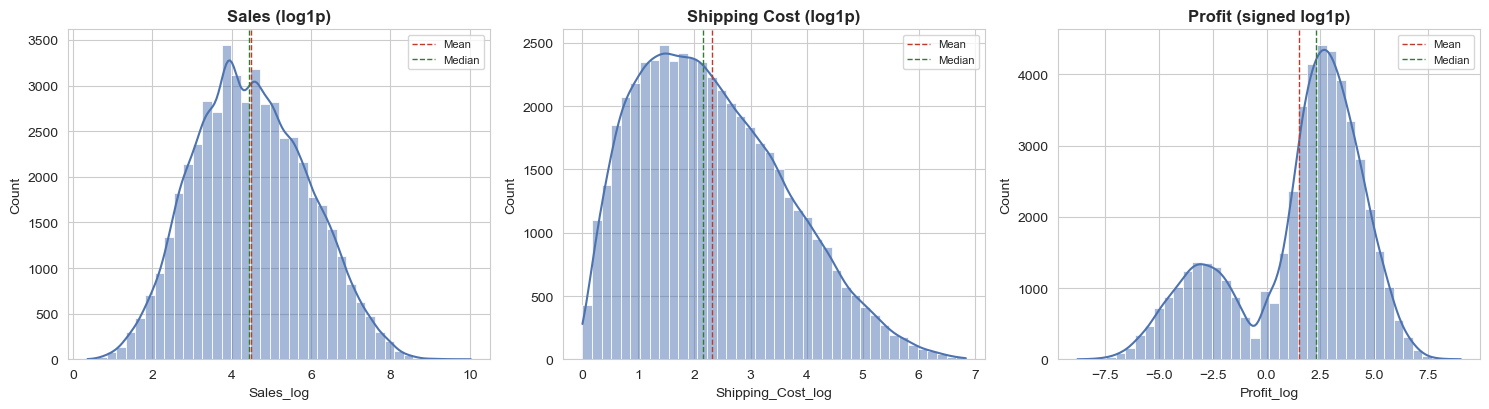

In [51]:

df_log = df_model.copy()
df_log["Sales_log"] = np.log1p(df_log["Sales"])
df_log["Shipping_Cost_log"] = np.log1p(df_log["Shipping Cost"])
df_log["Profit_log"] = np.sign(df_log["Profit"]) * np.log1p(np.abs(df_log["Profit"]))

log_cols = ["Sales_log", "Shipping_Cost_log", "Profit_log"]
titles = ["Sales (log1p)", "Shipping Cost (log1p)", "Profit (signed log1p)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(axes, log_cols, titles):
    sns.histplot(df_log[col], bins=40, kde=True, color=PRIMARY, ax=ax)
    ax.axvline(df_log[col].mean(), color=MEAN_COLOR, linestyle="--", linewidth=1, label="Mean")
    ax.axvline(df_log[col].median(), color=MEDIAN_COLOR, linestyle="--", linewidth=1, label="Median")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


Profit_log was only used to check the distribution shape; the final model trains on the original Profit.

## 6. Final Data Preparation for Modeling

### 6.0 Convert Categorical Columns to Numbers (One-Hot Encoding)


In [52]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Number of columns before encoding:", X_train.shape[1])
print("Number of columns after encoding:", X_train_encoded.shape[1])

X_train, X_test = X_train_encoded, X_test_encoded
X_train.head()

Number of columns before encoding: 53
Number of columns after encoding: 235


,Sales,Quantity,Discount,Shipping Cost,Returned,Order Month,Order Year,Order DayOfWeek,Order Quarter,Order Week,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,252.160004,8,0.0,13.449,0,10,2012,0,4,42,...,False,False,True,False,False,False,False,False,False,False
1,193.279999,2,0.0,9.627,0,10,2012,0,4,42,...,False,False,False,False,False,False,False,False,False,False
2,35.439999,4,0.0,1.371,0,10,2012,0,4,42,...,False,False,False,False,False,False,False,False,False,False
3,71.599998,2,0.0,3.787,0,10,2012,0,4,42,...,False,False,False,False,False,False,False,False,False,False
4,56.119999,2,0.0,4.718,0,10,2012,0,4,42,...,True,False,False,False,False,False,False,False,False,False


### 6.1 Train/Test Shapes



In [53]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (39700, 235)
Test: (9970, 235)


### 6.2 Comparing a Few Simple Scalers


In [54]:
scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "Robust": RobustScaler(),
}

scaler_scores = {}

for name, scaler in scalers.items():
    X_train_try = X_train.copy()
    X_test_try = X_test.copy()

    X_train_try[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test_try[numeric_features] = scaler.transform(X_test[numeric_features])

    quick_model = LinearRegression()
    quick_model.fit(X_train_try, y_train)

    test_r2 = quick_model.score(X_test_try, y_test)
    scaler_scores[name] = test_r2

    print(f"{name} Scaler -> Test R2: {test_r2:.4f}")

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print("\nbest Scaler:", best_scaler_name)


Standard Scaler -> Test R2: 0.6625
MinMax Scaler -> Test R2: 0.6625
Robust Scaler -> Test R2: 0.6625

best Scaler: MinMax


For tree-based models (Decision Tree, Random Forest) the choice of scaler doesn't matter much, but since all models use the same data, we keep the winning scaler for everything.

In [55]:
final_scaler = scalers[best_scaler_name]

X_train[numeric_features] = final_scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = final_scaler.transform(X_test[numeric_features])

print("number of columns:", X_train.shape[1])
X_train.head()


number of columns: 235


,Sales,Quantity,Discount,Shipping Cost,Returned,Order Month,Order Year,Order DayOfWeek,Order Quarter,Order Week,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,0.011119,0.538462,0.0,0.014404,0.0,0.818182,0.333333,0.0,1.0,0.803922,...,False,False,True,False,False,False,False,False,False,False
1,0.008518,0.076923,0.0,0.010310,0.0,0.818182,0.333333,0.0,1.0,0.803922,...,False,False,False,False,False,False,False,False,False,False
2,0.001546,0.230769,0.0,0.001466,0.0,0.818182,0.333333,0.0,1.0,0.803922,...,False,False,False,False,False,False,False,False,False,False
3,0.003143,0.076923,0.0,0.004054,0.0,0.818182,0.333333,0.0,1.0,0.803922,...,False,False,False,False,False,False,False,False,False,False
4,0.002459,0.076923,0.0,0.005052,0.0,0.818182,0.333333,0.0,1.0,0.803922,...,True,False,False,False,False,False,False,False,False,False


## 7. Modeling

### 7.1 Baseline Model

In [56]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 7.2 Other Models

In [57]:
X_tr_fit, X_val_fit, y_tr_fit, y_val_fit = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

models_basic = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=3000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=2000),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=4,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=4,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.8,
        min_samples_leaf=5,
        validation_fraction=0.15,
        n_iter_no_change=20,
        tol=1e-4,
        random_state=42
    ),
}

trained_models = {}

for name, model in models_basic.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Basic models trained.")


Basic models trained.


### 7.2.1 XGBoost Models


In [58]:
from xgboost import XGBRegressor

models_xgb = {
    "xgb_model": XGBRegressor(
        n_estimators=1500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=3,
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=-1
    ),

    "xgb_model_reg": XGBRegressor(
        n_estimators=1500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        min_child_weight=5,
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=-1
    ),
}

for name, model in models_xgb.items():
    model.fit(X_tr_fit, y_tr_fit, eval_set=[(X_val_fit, y_val_fit)], verbose=False)
    trained_models[name] = model

print("XGBoost models trained.")


XGBoost models trained.


### 7.3 Polynomial Regression


In [59]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly_num = poly.fit_transform(X_train[numeric_features])
X_test_poly_num = poly.transform(X_test[numeric_features])

poly_feature_names = poly.get_feature_names_out(numeric_features)

X_train_poly_num_df = pd.DataFrame(X_train_poly_num, columns=poly_feature_names, index=X_train.index)
X_test_poly_num_df = pd.DataFrame(X_test_poly_num, columns=poly_feature_names, index=X_test.index)

cat_cols = []
for col in X_train.columns:
    if col not in numeric_features:
        cat_cols.append(col)

X_train_poly = pd.concat([X_train_poly_num_df, X_train[cat_cols]], axis=1)
X_test_poly = pd.concat([X_test_poly_num_df, X_test[cat_cols]], axis=1)

print("Number of columns for Polynomial Regression:", X_train_poly.shape[1])

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)


Number of columns for Polynomial Regression: 1270


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 7.4 CatBoost (native categorical handling)


In [60]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200
)

catboost_model.fit(
    X_train_cb, y_train,
    cat_features=catboost_cat_cols,
    eval_set=(X_test_cb, y_test),
    use_best_model=True
)

0:	learn: 60.3822829	test: 61.7168980	best: 61.7168980 (0)	total: 332ms	remaining: 16m 34s
200:	learn: 31.0523915	test: 30.1131488	best: 30.1131488 (200)	total: 1m 4s	remaining: 14m 52s
400:	learn: 28.6457877	test: 27.9351069	best: 27.9351069 (400)	total: 2m	remaining: 12m 58s
600:	learn: 27.5294825	test: 27.0369703	best: 27.0364049 (599)	total: 2m 55s	remaining: 11m 40s
800:	learn: 26.7323938	test: 26.5721226	best: 26.5721226 (800)	total: 3m 53s	remaining: 10m 41s
1000:	learn: 26.2465693	test: 26.3228197	best: 26.3211570 (993)	total: 4m 56s	remaining: 9m 52s
1200:	learn: 25.8614172	test: 26.1792545	best: 26.1780677 (1197)	total: 5m 53s	remaining: 8m 49s
1400:	learn: 25.4939493	test: 26.0844379	best: 26.0841538 (1399)	total: 6m 56s	remaining: 7m 55s
1600:	learn: 25.2037672	test: 26.0092403	best: 26.0092403 (1600)	total: 7m 51s	remaining: 6m 52s
1800:	learn: 24.9371275	test: 25.9392792	best: 25.9391854 (1799)	total: 8m 48s	remaining: 5m 51s
2000:	learn: 24.6035947	test: 25.8036695	best:

CatBoostRegressor(depth=6, early_stopping_rounds=200, eval_metric='MAE', iterations=3000, l2_leaf_reg=3, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=200)

## 8. Model Evaluation

In [61]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name="model"):
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    return {
        "model": name,
        "train_MAE": mean_absolute_error(y_tr, y_pred_train),
        "test_MAE": mean_absolute_error(y_te, y_pred_test),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr, y_pred_train)),
        "test_RMSE": np.sqrt(mean_squared_error(y_te, y_pred_test)),
        "train_R2": r2_score(y_tr, y_pred_train),
        "test_R2": r2_score(y_te, y_pred_test),
    }


In [62]:
results_list = []
results_list.append(
    evaluate(model_linear, X_train, y_train, X_test, y_test, "Linear Regression")
)

for name, model in trained_models.items():
    results_list.append(
        evaluate(model, X_train, y_train, X_test, y_test, name)
    )

results_list.append(
    evaluate(model_poly, X_train_poly, y_train, X_test_poly, y_test, "Polynomial Regression")
)

results_list.append(
    evaluate(catboost_model, X_train_cb, y_train, X_test_cb, y_test, "CatBoost")
)

results_df = pd.DataFrame(results_list)
results_df.round(4)


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,41.0826,41.7866,99.0629,99.2151,0.6713,0.6625
1,Ridge,42.8841,43.6554,102.3010,104.9847,0.6495,0.6221
2,Lasso,40.8766,41.5227,99.1314,99.4385,0.6709,0.6610
3,ElasticNet,59.4558,59.9040,148.6237,146.8286,0.2602,0.2609
4,DecisionTree,33.7129,39.4094,77.1957,119.7221,0.8004,0.5086
5,RandomForest,20.5534,33.9350,61.0512,92.8316,0.8752,0.7045
6,GradientBoosting,32.5889,35.7102,70.0368,91.9486,0.8357,0.7101
7,xgb_model,28.7368,34.7777,62.1434,96.0380,0.8707,0.6838
8,xgb_model_reg,31.9085,35.5676,72.1514,96.8253,0.8257,0.6786
9,Polynomial Regression,36.6603,43.0591,75.6525,106.8545,0.8083,0.6085


### 8.0 Visual Comparison of Test Results


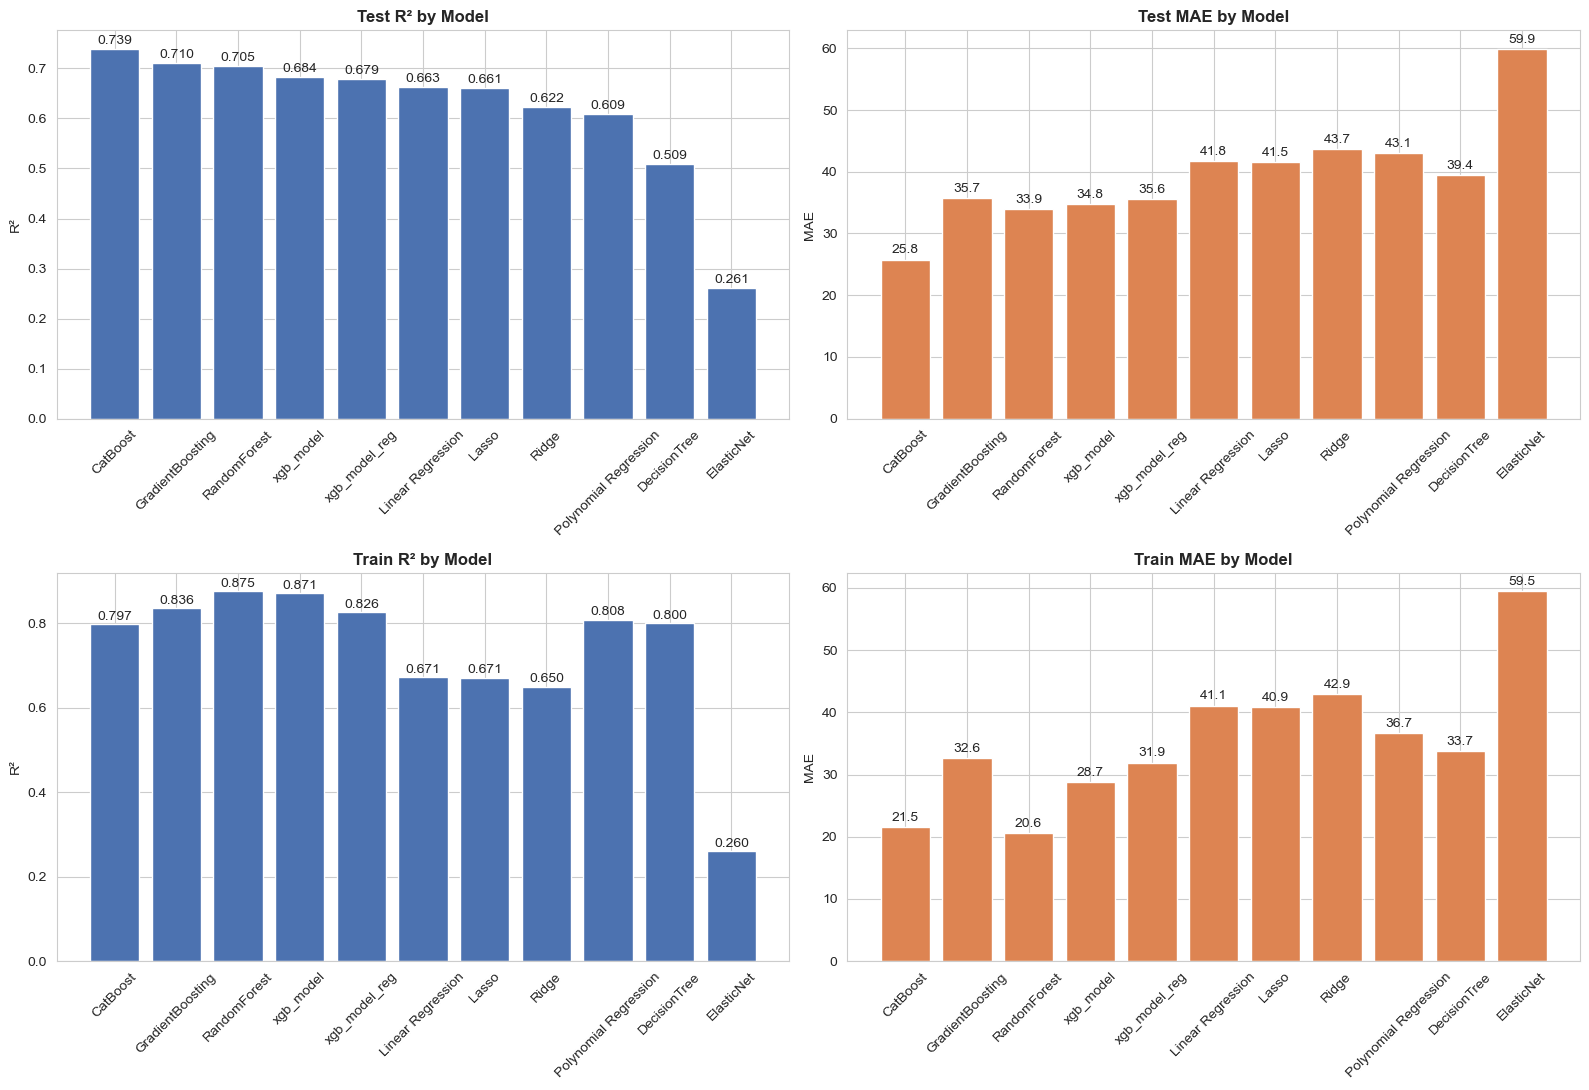

In [72]:
plot_df = results_df.sort_values("test_R2", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


axes[0, 0].bar(plot_df["model"], plot_df["test_R2"], color=PRIMARY)
axes[0, 0].set_title("Test R² by Model")
axes[0, 0].set_ylabel("R²")
axes[0, 0].tick_params(axis="x", rotation=45)

for i, value in enumerate(plot_df["test_R2"]):
    axes[0, 0].text(i, value + 0.01, f"{value:.3f}", ha="center")


axes[0, 1].bar(plot_df["model"], plot_df["test_MAE"], color=SECONDARY)
axes[0, 1].set_title("Test MAE by Model")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].tick_params(axis="x", rotation=45)

for i, value in enumerate(plot_df["test_MAE"]):
    axes[0, 1].text(i, value + 1, f"{value:.1f}", ha="center")


axes[1, 0].bar(plot_df["model"], plot_df["train_R2"], color=PRIMARY)
axes[1, 0].set_title("Train R² by Model")
axes[1, 0].set_ylabel("R²")
axes[1, 0].tick_params(axis="x", rotation=45)

for i, value in enumerate(plot_df["train_R2"]):
    axes[1, 0].text(i, value + 0.01, f"{value:.3f}", ha="center")


axes[1, 1].bar(plot_df["model"], plot_df["train_MAE"], color=SECONDARY)
axes[1, 1].set_title("Train MAE by Model")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].tick_params(axis="x", rotation=45)

for i, value in enumerate(plot_df["train_MAE"]):
    axes[1, 1].text(i, value + 1, f"{value:.1f}", ha="center")

plt.tight_layout()
plt.show()

### 8.1 Checking Overfitting via the Train/Test Gap

In [64]:
results_df["R2_gap"] = results_df["train_R2"] - results_df["test_R2"]
results_df[["model", "train_R2", "test_R2", "R2_gap"]].sort_values("test_R2", ascending=False).round(4)

,model,train_R2,test_R2,R2_gap
10,CatBoost,0.7970,0.7390,0.0579
6,GradientBoosting,0.8357,0.7101,0.1256
5,RandomForest,0.8752,0.7045,0.1706
7,xgb_model,0.8707,0.6838,0.1869
8,xgb_model_reg,0.8257,0.6786,0.1471
0,Linear Regression,0.6713,0.6625,0.0088
2,Lasso,0.6709,0.6610,0.0099
1,Ridge,0.6495,0.6221,0.0274
9,Polynomial Regression,0.8083,0.6085,0.1998
4,DecisionTree,0.8004,0.5086,0.2918


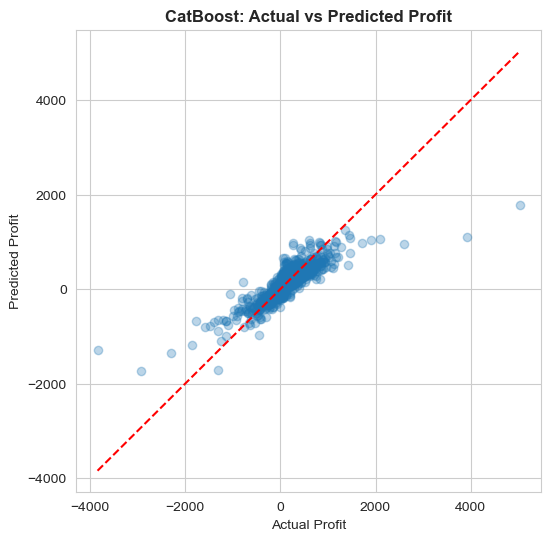

In [65]:
y_pred = catboost_model.predict(X_test_cb)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("CatBoost: Actual vs Predicted Profit")
plt.show()

## 9. Model Tuning — Grid Search + Cross-Validation per Model



In [66]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

### 9.1 Grid Search for RandomForest

In [ ]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 18, None],
    "min_samples_leaf": [2, 4, 8],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("RandomForest best params:", rf_search.best_params_)

### 9.1.1 Cross Validation for RandomForest (3-Fold)

In [ ]:
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=3, scoring="r2")

print("RandomForest CV scores:", rf_cv_scores)
print("RandomForest average R2:", round(rf_cv_scores.mean(), 4))

### 9.1.2 Cross Validation for RandomForest (5-Fold)

Same check, just with 5 folds instead of 3. If the average stays close to the 3-fold result above, that's a good sign — the score is stable, not just luck.

In [ ]:
rf_cv5_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2")

print("RandomForest CV scores (5-fold):", rf_cv5_scores)
print("RandomForest average R2 (5-fold):", round(rf_cv5_scores.mean(), 4))

### 9.2 Grid Search for GradientBoosting

In [ ]:
gb_param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.06],
}

gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

print("GradientBoosting best params:", gb_search.best_params_)

### 9.2.1 Cross Validation for GradientBoosting (3-Fold)

In [ ]:
gb_cv_scores = cross_val_score(best_gb, X_train, y_train, cv=3, scoring="r2")

print("Gradient Boosting CV scores:", gb_cv_scores)
print("Gradient Boosting average R2:", round(gb_cv_scores.mean(), 4))

### 9.2.2 Cross Validation for GradientBoosting (5-Fold)

Same check, just with 5 folds instead of 3. If the average stays close to the 3-fold result above, that's a good sign — the score is stable, not just luck.

In [ ]:
gb_cv5_scores = cross_val_score(best_gb, X_train, y_train, cv=5, scoring="r2")

print("Gradient Boosting CV scores (5-fold):", gb_cv5_scores)
print("Gradient Boosting average R2 (5-fold):", round(gb_cv5_scores.mean(), 4))

### 9.3 Grid Search for XGBoost

In [ ]:
xgb_param_grid = {
    "n_estimators": [500, 1000],
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.06],
    "reg_lambda": [1, 5],
}

xgb_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("XGBoost best params:", xgb_search.best_params_)

### 9.3.1 Cross Validation for XGBoost (3-Fold)

In [ ]:
xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=3, scoring="r2")

print("XGBoost CV scores:", xgb_cv_scores)
print("XGBoost average R2:", round(xgb_cv_scores.mean(), 4))

### 9.3.2 Cross Validation for XGBoost (5-Fold)

Same check, just with 5 folds instead of 3. If the average stays close to the 3-fold result above, that's a good sign — the score is stable, not just luck.

In [ ]:
xgb_cv5_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring="r2")

print("XGBoost CV scores (5-fold):", xgb_cv5_scores)
print("XGBoost average R2 (5-fold):", round(xgb_cv5_scores.mean(), 4))

### 9.4 Final Comparison (Baseline Models + the Three Tuned Models)

In [ ]:
best_rf_result = evaluate(best_rf, X_train, y_train, X_test, y_test, "RandomForest (tuned)")
best_gb_result = evaluate(best_gb, X_train, y_train, X_test, y_test, "GradientBoosting (tuned)")
best_xgb_result = evaluate(best_xgb, X_train, y_train, X_test, y_test, "XGBoost (tuned)")

final_results = pd.concat([
    results_df[["model", "train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "train_R2", "test_R2"]],
    pd.DataFrame([best_rf_result, best_gb_result, best_xgb_result]),
], ignore_index=True)

final_results["R2_gap"] = final_results["train_R2"] - final_results["test_R2"]
final_results.sort_values("test_R2", ascending=False).round(4)